<a href="https://colab.research.google.com/github/purbak/Neuronal_activity_analysis/blob/main/Neuronal_activity_analysis1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Aim:  
To find galaninergic neurons that respond to Stress and Anxiety

### Experiment:
 We imaged 5 day old GCaMP expressing zebrafish while exposing them to anxiety and stress stimuli. GCaMP is a fluorescent protein that is sensitive to calcium and therefore marks neuronal activity. Fish was exposed to dark periodically to stimulate anxiety. after two cycles of dark exposure, they were exposed to Nacl to stimulate physiological stress.

GCaMP intensity data for galaninergic neurons were processed.<br>  As a result we have frequency of neuron activity in following windows of stimulus: Light, Dark, Light, Dark, Light, Dark, Dark + Salt

### Method:
We have used 5% change of frequency as threshold to indicate change in neuronal activity between stimulus windows.<br>
We define anxiety responding neurons as <br>
We define stress responding neurons as instances that show >= 5% change last two windows, Dark and Dark + Salt.<br>

### Analysis

#### Preprocessing

In [4]:
#import necessary libraries
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
#from sklearn.cluster import KMeans
import seaborn as sns
from scipy.stats import wilcoxon
#from sklearn.metrics import silhouette_score
import scipy.io
from scipy.stats import zscore

In [5]:
#load frequency summary data
colnames = ['Light1', 'Dark1', 'Light2', 'Dark2', 'Light3', 'presalt', 'salt']
freq = pd.read_csv(os.path.join('simulated_freq.csv'), names=colnames)
freq = freq.iloc[1:,:]
freq = freq.astype(float)
freq.shape

(81, 7)

In [6]:
#load drift corrected dF/Fo data. This will only be used to if neuron definition of stress and anxiety activity is correct. Data is not used directly for clustering.
dF_Fo_path = "simulated_data.mat"
dF_Fo_mat = scipy.io.loadmat(dF_Fo_path)

# Extract the array
dF_Fo = dF_Fo_mat["dff"]

# Ensure it's a plain numpy array (remove extra dimensions if needed)
dF_Fo = np.array(dF_Fo, dtype=float).squeeze()
dF_Fo = dF_Fo.T

#normalize dF/Fo data
dF_Fo_z = zscore(dF_Fo, axis=1)

In [7]:
#load ground truth to test analysis methods
ground_truth_spikes = dF_Fo_mat["ground_spike"]
neuron_type = dF_Fo_mat["neuron_types_ground"]
neuron_type = np.char.strip(neuron_type)

#### Anxiety responding neuron defined by relative difference

In [8]:
#Calculating relative difference between phases

# Absolute difference between phases
rel_diff = freq.iloc[:, 1:].values - freq.iloc[:, :-1].values
rel_diff_df = pd.DataFrame(rel_diff, columns=['Dark1_Light1', 'Light2_Dark1', 'Dark2_Light2', 'Light3_Dark2', 'Presalt_Light3', 'Salt_Presalt'])
before = freq.iloc[:, :-1].values
after = freq.iloc[:, 1:].values

rel_change = np.zeros_like(rel_diff)

# Case 1: denominator != 0 → check relative change threshold
mask_nonzero = before != 0
rel_change[mask_nonzero] = (
    np.abs(rel_diff[mask_nonzero]) / np.abs(before[mask_nonzero])
)

#in case of zero division error, if after value is non zero, it is considered a change.
# Case 2: denominator == 0 → check if after is nonzero
mask_zero = before == 0
rel_change[mask_zero] = np.where(
    after[mask_zero] != 0,
    np.inf,   # treat as strong change
    0         # no change
)


In [29]:
def compute_mask(change_signed):
    # Dark-preferring neurons
    dark_mask = (
        (change_signed[:, 0] >= 0) &
        (change_signed[:, 1] <= 0) &
        (change_signed[:, 2] >= 0) &
        (change_signed[:, 3] <= 0)
    )
    #strong dark
    dark_mask_st = (
        (change_signed[:, 0] > 0) &
        (change_signed[:, 2] > 0)
    )

    # Light-preferring neurons
    light_mask = (
        (change_signed[:, 0] <= 0) &
        (change_signed[:, 2] <= 0) &
        (change_signed[:, 1] >= 0) &
        (change_signed[:, 3] >= 0)
    )
    #strong light
    light_mask_st = (
        (change_signed[:, 1] > 0) &
        (change_signed[:, 3] > 0)
    )

    # Non-responsive neurons
    non_responsive = np.all(change_signed == 0, axis=1)

    # Everything else
    undefined = ~(light_mask_st | dark_mask_st | non_responsive)

    return dark_mask, light_mask, non_responsive, undefined, dark_mask_st, light_mask_st


In [30]:
#Explore thresholds of relative change and compare with ground truth
thresholds = [1, 2, 3, 4, 5]

results = []

for t in thresholds:
    change_filter = np.zeros_like(rel_diff, dtype=int)
    change_filter = rel_change > t
    change_signed = rel_diff * change_filter
    # Compute masks
    dark_mask, light_mask, non_responsive, undefined, dark_mask_st, light_mask_st = compute_mask(change_signed)
    # Evaluate against ground truth
    results.append({
    "threshold": t,
    "undefined": undefined.sum(),
    "non_responsive": non_responsive.sum(),
    "strict_dark": dark_mask_st.sum(),
    "strict_light": light_mask_st.sum(),
    "light_mask": light_mask.sum(),
    "dark_mask": dark_mask.sum(),
    "percentage coverage": (light_mask.sum() + dark_mask.sum() + undefined.sum() + non_responsive.sum()) / len(freq),
    "light_detected": np.sum(
        light_mask & np.isin(neuron_type, ["light", "mixed"])
    ),
    "dark_detected": np.sum(
        dark_mask & np.isin(neuron_type, ["dark", "mixed"])
    ),
    "false_light": np.sum(
        light_mask & np.isin(neuron_type, ["dark", "salt"])
    ),
    "false_dark": np.sum(
        dark_mask & np.isin(neuron_type, ["light", "salt"])
    ),
})

In [31]:
results_df = pd.DataFrame(results)
results_df.head()

,threshold,undefined,non_responsive,strict_dark,strict_light,light_mask,dark_mask,percentage coverage,light_detected,dark_detected,false_light,false_dark
0,1,36,1,18,26,49,42,1.580247,34,25,8,9
1,2,32,5,18,26,53,48,1.703704,34,26,9,10
2,3,28,11,17,25,56,48,1.765432,35,26,9,10
3,4,29,16,16,20,60,49,1.901235,37,27,11,10
4,5,34,20,13,14,60,52,2.049383,37,28,11,12


Couple of interesting factors we notice from the threshold tuning:


*   False Positives (false_light, false_dark) increases with increasing threshold. Why is this interesting? We expect increasing relative change threshold should weed out non responding or weakly responding neurons. Instead we see opposite effect.
*   We see increase in non_responsive neurons with increase in threshold. This is what is expected with increase in threshold.
*   Increase in light mask and dark mask. From where are we getting the supply of neurons to cause the rise in light mask, dark mask and non responding neurons with threshold increasing. Which neurons are being reassigned to light or dark mask after each step? The undefined and strict dark/light are providing for light, dark and non responding. Non responding neurons are also in light and dark mask because of (== 0) condition applied in light mask and dark mask.



#### Anxiety responding neurons defined by relative difference AND absolute difference

We need to change strategy in the definition of responding neurons. Because relative change starts to bias small baseline over high baseline neurons. Small change in small baseline shows larger relative change compared to change in large baseline activity neurons. This is what's causing false positive rise with threshold increase.

In [35]:
#Add absolute difference as an additional factor for selection criteria
#data abs differences
abs_diff = abs(rel_diff.copy()) #take care of nomenclature later
np.percentile(abs_diff, [50, 75, 90, 95])

array([0.04239401, 0.06735028, 0.08229426, 0.08977556])

(array([31.,  0., 53.,  0., 42.,  0., 43.,  3.,  0., 28.,  0., 11.,  0.,
         4.,  0.,  0.,  6.,  0.,  2.,  0.,  2.,  0.,  0.,  1.,  0.,  3.,
         0.,  0.,  0.,  0.,  2.,  0.,  3.,  0.,  4.,  0.,  0.,  4.,  0.,
         3.,  0.,  3.,  0.,  0.,  7.,  0.,  6.,  0., 11.,  0.,  1., 13.,
         0., 11.,  0., 17.,  0.,  0., 19.,  0., 16.,  0., 16.,  0.,  0.,
        14.,  0., 18.,  0.,  6.,  0.,  0.,  6.,  0., 22.,  0., 11.,  0.,
         0.,  9.,  0.,  5.,  0.,  9.,  0.,  0.,  5.,  0.,  3.,  0.,  7.,
         0.,  0.,  2.,  0.,  1.,  0.,  1.,  0.,  2.]),
 array([0.        , 0.00107244, 0.00214489, 0.00321733, 0.00428977,
        0.00536222, 0.00643466, 0.0075071 , 0.00857955, 0.00965199,
        0.01072443, 0.01179688, 0.01286932, 0.01394176, 0.01501421,
        0.01608665, 0.01715909, 0.01823154, 0.01930398, 0.02037642,
        0.02144887, 0.02252131, 0.02359375, 0.0246662 , 0.02573864,
        0.02681108, 0.02788353, 0.02895597, 0.03002841, 0.03110085,
        0.0321733 , 0.0332

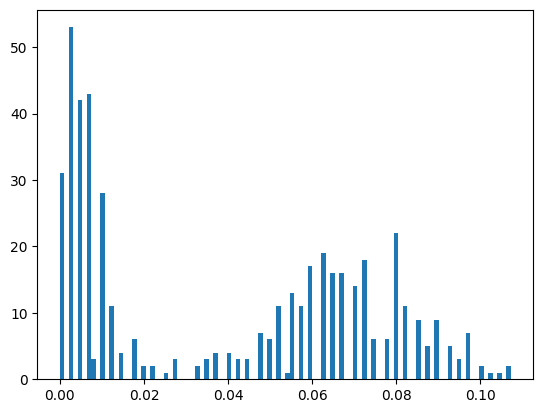

In [36]:
plt.hist(abs_diff.flatten(), bins=100)

There are two peaks correspinding to noise and signal.
Absolute difference threshold is chosen at the separation point between noise and signal distributions

In [37]:
#Explore thresholds of relative change and compare with ground truth
thresholds = [1, 2, 3, 4, 5]

results = []
abs_threshold = 0.04

for t in thresholds:

    change_filter = np.zeros_like(rel_diff, dtype=int)

    change_filter = (
    (rel_change > t) &
    (abs_diff > abs_threshold)
      )
    change_signed = rel_diff * change_filter
    # Compute masks
    dark_mask, light_mask, non_responsive, undefined, dark_mask_st, light_mask_st = compute_mask(change_signed)
    # Evaluate against ground truth
    results.append({
    "threshold": t,
    "undefined": undefined.sum(),
    "non_responsive": non_responsive.sum(),
    "strict_dark": dark_mask_st.sum(),
    "strict_light": light_mask_st.sum(),
    "light_mask": light_mask.sum(),
    "dark_mask": dark_mask.sum(),
    "percentage coverage": (light_mask.sum() + dark_mask.sum() + undefined.sum() + non_responsive.sum()) / len(freq),
    "light_detected": np.sum(
        light_mask & np.isin(neuron_type, ["light", "mixed"])
    ),
    "dark_detected": np.sum(
        dark_mask & np.isin(neuron_type, ["dark", "mixed"])
    ),
    "false_light": np.sum(
        light_mask & np.isin(neuron_type, ["dark", "salt"])
    ),
    "false_dark": np.sum(
        dark_mask & np.isin(neuron_type, ["light", "salt"])
    ),
})

In [38]:
results_df = pd.DataFrame(results)
results_df.head()

,threshold,undefined,non_responsive,strict_dark,strict_light,light_mask,dark_mask,percentage coverage,light_detected,dark_detected,false_light,false_dark
0,1,24,15,17,25,58,50,1.814815,35,27,11,11
1,2,24,15,17,25,58,50,1.814815,35,27,11,11
2,3,26,15,16,24,58,50,1.839506,35,27,11,11
3,4,28,18,16,19,61,50,1.938272,37,27,12,11
4,5,32,22,13,14,61,53,2.074074,37,28,12,13


In [ ]:
rel_diff_df.head()

Exploring relative thresholds to distinguish neuronal types

In [ ]:
thresholds = [1, 2, 3, 4, 5]

for t in thresholds:
    change_filter = (
        np.abs(rel_diff) / (np.abs(before) + 1e-6)
    ) > t

    # compute masks
    # compare with ground truth neuron_type

### Identification of anxiety responding neurons

In [ ]:
# dark is defined by all neurons with no or reduced activity in all light phases (col 1,3) and no activity or increased activity in all dark phases (col 0,3) columns of rel_diff
dark_mask = (change_signed[:, 0] >= 0) & (change_signed[:, 1] <= 0) & (change_signed[:, 2] >= 0) & (change_signed[:, 3] <= 0)
#light is defined by all neurons with no or reduced activity in all dark phases and no activity or increased activity in all dark phases (col 0,3) columns of rel_diff
light_mask = (change_signed[:, 0] <= 0) & (change_signed[:, 2] <= 0) & (change_signed[:, 1] >= 0) & (change_signed[:, 3] >= 0)
#pick out non responsive
non_responsive = np.all(change_signed == 0, axis=1)
undefined = ~(light_mask | dark_mask | non_responsive)

In [ ]:
neuron_type[light_mask]

In [ ]:
neuron_type[freq[light_mask].index]

In [ ]:
print("Percentage of Light Responsive Neurons:", light_mask.mean() * 100)
print("Percentage of Dark Responsive Neurons:", dark_mask.mean() * 100)
print("Percentage of Non-Responsive Neurons:", non_responsive.mean() * 100)
print("Percentage of Undefined Neurons:", undefined.mean() * 100)

In [ ]:
freq.iloc[undefined, :]

In [ ]:
change_signed[undefined]

In [ ]:
#test how many are consecutive up or down. does it match to undefined number
consecutive_mask = ((change_signed[:, 0] * change_signed[:, 1] > 0) |
                   (change_signed[:, 1] * change_signed[:, 2] > 0) |
                   (change_signed[:, 2] * change_signed[:, 3] > 0))

#but stable value will have 0.0 -> 0.0 so we need to exclude those
#check within consecutive mask, if any value is non_zero
zero_mask = np.any(change_signed[:, :4] == 0, axis=1)
consecutive_mask_zeroexcluded = consecutive_mask & ~zero_mask

In [ ]:
consecutive_mask.sum()

In [ ]:
consecutive_mask_zeroexcluded.sum()

In [ ]:
#collect subtypes of dark
#within dark responsive, there are two types again, one with increase activity in dark phases,
allphase_dark_active = dark_mask & ((change_signed[:,0]>0) & (change_signed[:,2]>0))
twophase_dark_1_active = dark_mask & ~(allphase_dark_active) & (change_signed[:,0]>0)
twophase_dark_2_active = dark_mask & ~(allphase_dark_active) & (change_signed[:,2]>0)

#and another with reduced activity in light phases.
allphase_dark_reduced = dark_mask & ((change_signed[:,1]<0) & (change_signed[:,3]<0))
twophase_dark_1_reduced = dark_mask & ~(allphase_dark_reduced) & (change_signed[:,1]<0)
twophase_dark_2_reduced = dark_mask & ~(allphase_dark_reduced) & (change_signed[:,2]<0)
undef_dark = dark_mask & ~(allphase_dark_active|twophase_dark_1_active|twophase_dark_2_active|allphase_dark_reduced|twophase_dark_1_reduced|twophase_dark_2_reduced)

In [ ]:
print("Total dark responsive neurons:", dark_mask.sum())
print("All phase dark responsive neurons:", allphase_dark.sum())
print("Two phase dark responsive neurons (phase 1):", twophase_dark_1.sum())
print("Two phase dark responsive neurons (phase 2):", twophase_dark_2.sum())
print("Undefined dark responsive neurons:", undef_dark.sum())

In [ ]:
change_signed[allphase_dark]

In [ ]:
change_signed[twophase_dark_1]

In [12]:
#light responsive subtypes
allphase_light = light_mask & ((change_signed[:,1]>0) & (change_signed[:,3]>0))
twophase_light_2 = light_mask & ~(allphase_light) & (change_signed[:,1]>0)
twophase_light_3 = light_mask & ~(allphase_light) & (change_signed[:,3]>0)
twophase_light_1 = light_mask & ~(allphase_light) & ~(twophase_light_2) & ~(twophase_light_3)& (change_signed[:,0]< 0)
undef_light = light_mask & ~(allphase_light|twophase_light_1|twophase_light_2|twophase_light_3)

In [13]:
print("Total light responsive neurons:", light_mask.sum())
print("All phase light responsive neurons:", allphase_light.sum())
print("Two phase light responsive neurons (phase 1):", twophase_light_1.sum())
print("Two phase light responsive neurons (phase 2):", twophase_light_2.sum())
print("Two phase light responsive neurons (phase 3):", twophase_light_3.sum())
print("Undefined light responsive neurons:", undef_light.sum())

Total light responsive neurons: 60
All phase light responsive neurons: 14
Two phase light responsive neurons (phase 1): 0
Two phase light responsive neurons (phase 2): 8
Two phase light responsive neurons (phase 3): 7
Undefined light responsive neurons: 31


In [14]:
change_signed[allphase_light]

array([[-0.        ,  0.06733167, -0.        ,  0.09725686, -0.        ,
        -0.        ],
       [-0.        ,  0.05486284, -0.        ,  0.06483791, -0.        ,
        -0.        ],
       [-0.        ,  0.06982544, -0.        ,  0.06234414, -0.        ,
        -0.        ],
       [-0.        ,  0.08478803, -0.        ,  0.05236908, -0.        ,
        -0.        ],
       [-0.        ,  0.0723192 , -0.        ,  0.05985037, -0.        ,
         0.00498753],
       [-0.        ,  0.06483791, -0.        ,  0.06483791, -0.        ,
         0.01246883],
       [-0.        ,  0.06982544, -0.        ,  0.06234414, -0.        ,
         0.00997506],
       [-0.        ,  0.08229426, -0.        ,  0.06733167, -0.        ,
        -0.        ],
       [-0.        ,  0.09725686, -0.        ,  0.06483791, -0.        ,
         0.01995012],
       [-0.        ,  0.06733167, -0.        ,  0.05985037, -0.        ,
        -0.        ],
       [-0.        ,  0.05236908, -0.        ,  0.

In [15]:
change_signed[twophase_light_1]

array([], shape=(0, 6), dtype=float64)

In [16]:
change_signed[twophase_light_2]

array([[-0.        ,  0.0723192 , -0.        ,  0.        , -0.        ,
         0.        ],
       [-0.        ,  0.01246883, -0.        ,  0.        ,  0.        ,
         0.09480031],
       [-0.        ,  0.07481297, -0.        ,  0.        , -0.        ,
        -0.        ],
       [-0.        ,  0.06483791, -0.        ,  0.        , -0.        ,
         0.00498753],
       [-0.        ,  0.05236908, -0.        ,  0.        , -0.        ,
        -0.        ],
       [-0.        ,  0.08977556, -0.        , -0.        ,  0.        ,
         0.08980037],
       [-0.        ,  0.08229426, -0.        ,  0.        , -0.        ,
         0.        ],
       [-0.        ,  0.08478803, -0.        ,  0.        , -0.        ,
        -0.        ]])

In [17]:
change_signed[twophase_light_3]

array([[-0.        ,  0.        , -0.        ,  0.08977556, -0.        ,
        -0.        ],
       [-0.        ,  0.        , -0.        ,  0.06483791, -0.        ,
         0.        ],
       [-0.        , -0.        , -0.        ,  0.06483791, -0.        ,
         0.06486272],
       [-0.        ,  0.        , -0.        ,  0.0723192 , -0.        ,
        -0.        ],
       [-0.        , -0.        ,  0.        ,  0.06234414, -0.        ,
         0.07982531],
       [-0.        ,  0.        , -0.        ,  0.06483791, -0.        ,
         0.        ],
       [ 0.        , -0.        , -0.        ,  0.05735661, -0.        ,
         0.        ]])

In [18]:
#plot heatmap of z scored dF/F for light responsive, dark responsive anxiety neurons and non responsive neurons and all subtypes
light_allphase = freq.index[allphase_light]
light_twophase_1 = freq.index[twophase_light_1]
light_twophase_2 = freq.index[twophase_light_2]
light_twophase_3 = freq.index[twophase_light_3]
dark_allphase = freq.index[allphase_dark]
dark_twophase_1 = freq.index[twophase_dark_1]
dark_twophase_2 = freq.index[twophase_dark_2]
undefined_light = freq.index[undef_light]
undefined_dark = freq.index[undef_dark]
other_indices = freq.index[~(light_mask | dark_mask)]
new_order = (light_allphase.tolist() + light_twophase_1.tolist() + light_twophase_2.tolist() + light_twophase_3.tolist() +
             dark_allphase.tolist() + dark_twophase_1.tolist() + dark_twophase_2.tolist() +
             undefined_light.tolist() + undefined_dark.tolist() +
             other_indices.tolist())
# Reorder the original dF_Fo array
sorted_dF_Fo = dF_Fo_z[new_order, :-601]
# Plot heatmap of the reordered dF_Fo and add separators
plt.figure(figsize=(12, 8))
sns.heatmap(sorted_dF_Fo, cmap='viridis', cbar_kws={'label': 'dF/F'})
# Add horizontal lines to separate groups
current_cut = 0
for group in [light_allphase, light_twophase_1, light_twophase_2, light_twophase_3,
              dark_allphase, dark_twophase_1, dark_twophase_2,
              undefined_light, undefined_dark]:
    current_cut += len(group)
    plt.axhline(current_cut, color='blue', linestyle='--', linewidth=1)
# add black horizontal line to separate light responsive, dark responsive, undefined, and other neurons
plt.axhline(len(light_allphase) + len(light_twophase_1) + len(light_twophase_2) + len(light_twophase_3), color='red', linestyle='--', linewidth=1)
plt.axhline(len(light_allphase) + len(light_twophase_1) + len(light_twophase_2) + len(light_twophase_3) + len(dark_allphase) + len(dark_twophase_1) + len(dark_twophase_2), color='red', linestyle='--', linewidth=1)
plt.axhline(len(light_allphase) + len(light_twophase_1) + len(light_twophase_2) + len(light_twophase_3) + len(dark_allphase) + len(dark_twophase_1) + len(dark_twophase_2) + len(undefined_light) + len(undefined_dark), color='red', linestyle='--', linewidth=1)
#add vertical lines to separate light and dark phases
plt.axvline(401, color='black', linestyle='--', linewidth=1)
plt.axvline(401*2, color='black', linestyle='--', linewidth=1)
plt.axvline(401*3, color='black', linestyle='--', linewidth=1)
plt.axvline(401*4, color='black', linestyle='--', linewidth=1)
plt.axvline(401*5, color='black', linestyle='--', linewidth=1)
plt.axvline(401* 5 + 201, color='black', linestyle='--', linewidth=1)
plt.xlabel('Timepoints')
plt.ylabel('Neurons')
plt.title('Heatmap of dF/F over Time (Sorted by Light and Dark Responsive Neurons and Subtypes)')
plt.show()

NameError: name 'allphase_dark' is not defined

In [ ]:
#plot bar plot
subtype_counts = {
    'Light_responsive': light_mask.sum()/len(freq),
    'Dark_responsive': dark_mask.sum()/len(freq),
    'Non_responsive': non_responsive.sum()/len(freq),
    'Undefined': undefined.sum()/len(freq)
}
# Plot the counts
plt.figure(figsize=(10, 6))
sns.barplot(x=list(subtype_counts.keys()), y=list(subtype_counts.values()))
plt.title('Counts of Light and Dark Responsive Neuron Subtypes')
plt.ylabel('Number of Neurons')
plt.xticks(rotation=45)
plt.show()

In [ ]:
#plot bar plot of light responsive subtypes and dark responsive subtypes
subtype_counts = {
    'Light_All_Phase': allphase_light.sum()/len(freq),
    'Light_Two_Phase_1': twophase_light_1.sum()/len(freq),
    'Light_Two_Phase_2': twophase_light_2.sum()/len(freq),
    'Light_Two_Phase_3': twophase_light_3.sum()/len(freq),
    'Dark_All_Phase': allphase_dark.sum()/len(freq),
    'Dark_Two_Phase_1': twophase_dark_1.sum()/len(freq),
    'Dark_Two_Phase_2': twophase_dark_2.sum()/len(freq),
    'Undefined_Light': undef_light.sum()/len(freq),
    'Undefined_Dark': undef_dark.sum()/len(freq)
}
# Plot the counts
plt.figure(figsize=(10, 6))
sns.barplot(x=list(subtype_counts.keys()), y=list(subtype_counts.values()))
plt.title('Counts of Light and Dark Responsive Neuron Subtypes')
plt.ylabel('Number of Neurons')
plt.xticks(rotation=45)
plt.show()

In [ ]:
#combination with salt responsive neurons
allphase_light_salt_positive = allphase_light & (change_signed[:, 5]>0)
allphase_light_salt_negative = allphase_light & (change_signed[:, 5]<0)
allphase_light_salt_nochange = allphase_light & (change_signed[:, 5]==0)

allphase_dark_salt_positive = allphase_dark & (change_signed[:, 5]>0)
allphase_dark_salt_negative = allphase_dark & (change_signed[:, 5]<0)
allphase_dark_salt_nochange = allphase_dark & (change_signed[:, 5]==0)

twophase_light_1_salt_positive = twophase_light_1 & (change_signed[:, 5]>0)
twophase_light_1_salt_negative = twophase_light_1 & (change_signed[:, 5]<0)
twophase_light_1_salt_nochange = twophase_light_1 & (change_signed[:, 5]==0)

twophase_dark_1_salt_positive = twophase_dark_1 & (change_signed[:, 5]>0)
twophase_dark_1_salt_negative = twophase_dark_1 & (change_signed[:, 5]<0)
twophase_dark_1_salt_nochange = twophase_dark_1 & (change_signed[:, 5]==0)

twophase_light_2_salt_positive = twophase_light_2 & (change_signed[:, 5]>0)
twophase_light_2_salt_negative = twophase_light_2 & (change_signed[:, 5]<0)
twophase_light_2_salt_nochange = twophase_light_2 & (change_signed[:, 5]==0)

twophase_dark_2_salt_positive = twophase_dark_2 & (change_signed[:, 5]>0)
twophase_dark_2_salt_negative = twophase_dark_2 & (change_signed[:, 5]<0)
twophase_dark_2_salt_nochange = twophase_dark_2 & (change_signed[:, 5]==0)

twophase_light_3_salt_positive = twophase_light_3 & (change_signed[:, 5]>0)
twophase_light_3_salt_negative = twophase_light_3 & (change_signed[:, 5]<0)
twophase_light_3_salt_nochange = twophase_light_3 & (change_signed[:, 5]==0)



In [ ]:
#plot bar plot of light responsive subtypes and dark responsive subtypes with salt response as stacked bar plot
#prepare data for stacked bar plot salt responsive subtypes
#in percentages
subtypes = {
    'Light_All_Phase': {
        'Positive': allphase_light_salt_positive.sum(),
        'Negative': allphase_light_salt_negative.sum(),
        'NoChange': allphase_light_salt_nochange.sum()
    },
    'Light_Two_Phase_1': {
        'Positive': twophase_light_1_salt_positive.sum(),
        'Negative': twophase_light_1_salt_negative.sum(),
        'NoChange': twophase_light_1_salt_nochange.sum()
    },
    'Light_Two_Phase_2': {
        'Positive': twophase_light_2_salt_positive.sum(),
        'Negative': twophase_light_2_salt_negative.sum(),
        'NoChange': twophase_light_2_salt_nochange.sum()
    },
    'Light_Two_Phase_3': {
        'Positive': twophase_light_3_salt_positive.sum(),
        'Negative': twophase_light_3_salt_negative.sum(),
        'NoChange': twophase_light_3_salt_nochange.sum()
    },
    'Dark_All_Phase': {
        'Positive': allphase_dark_salt_positive.sum(),
        'Negative': allphase_dark_salt_negative.sum(),
        'NoChange': allphase_dark_salt_nochange.sum()
    },
    'Dark_Two_Phase_1': {
        'Positive': twophase_dark_1_salt_positive.sum(),
        'Negative': twophase_dark_1_salt_negative.sum(),
        'NoChange': twophase_dark_1_salt_nochange.sum()
    },
    'Dark_Two_Phase_2': {
        'Positive': twophase_dark_2_salt_positive.sum(),
        'Negative': twophase_dark_2_salt_negative.sum(),
        'NoChange': twophase_dark_2_salt_nochange.sum()
    }
}

# Convert to DataFrame
df = pd.DataFrame(subtypes).T
df = df/len(freq) * 100  # Convert to percentages
# Plot stacked bar plot
ax = df.plot(kind='bar', stacked=True, figsize=(10, 6), color=['lightgreen', 'salmon', 'lightgrey'])
# Style the plot
ax.set_title('Salt Responsive Subtypes')
ax.set_ylabel('Cell Count (%)')
ax.set_xlabel('Subtypes'                                   )
plt.xticks(rotation=45)
plt.legend(title='Salt Response')
plt.tight_layout()
plt.show()

actual data :   Light1 | Dark1| Light2 | Dark2 | Light3

relative freq:     (D1-L1)  (L2-D1)  (D2-L2) (L3-D2)
                    /L2         /D1   /L2     /D2

                                0/-             0/-
                                0/-
                                                0/-     


In [ ]:
#Sort within Light responsive neurons by their peak dF/F during light phases
#dark responsive subtypes
double_phase_dark_responsive = dark_mask & (change_signed[:, 0] > 0) & (change_signed[:, 2] > 0)
single_phase_dark_responsive_1 = dark_mask & (change_signed[:, 0] > 0) & ~double_phase_dark_responsive
single_phase_dark_responsive_2 = dark_mask & (change_signed[:, 2] > 0) & ~double_phase_dark_responsive
undefined_dark_responsive = dark_mask & ~double_phase_dark_responsive & ~single_phase_dark_responsive_1 & ~single_phase_dark_responsive_2

#light responsive subtypes
double_phase_light_responsive = light_mask &(change_signed[:, 1] > 0) & (change_signed[:, 3] > 0)
single_phase_light_responsive_1 = light_mask & (change_signed[:, 0] > 0) & ~double_phase_light_responsive
single_phase_light_responsive_2 = light_mask & (change_signed[:, 3] > 0) & ~double_phase_light_responsive

In [ ]:
freq[double_phase_dark_responsive]

In [ ]:
change_signed[double_phase_dark_responsive]

In [ ]:
#plot heatmap of dark responsive neurons sorted by their subtypes
dark_double_indices = freq[double_phase_dark_responsive].index
dark_single_1_indices = freq[single_phase_dark_responsive_1].index
dark_single_2_indices = freq[single_phase_dark_responsive_2].index
undefined_dark_indices = freq[undefined_dark_responsive].index
new_order = (dark_double_indices.tolist() + dark_single_1_indices.tolist() + dark_single_2_indices.tolist() + undefined_dark_indices.tolist())
# Reorder the original dF_Fo array
sorted_dF_Fo = dF_Fo_z[new_order, :-601]
# Plot heatmap of the reordered dF_Fo and add separators
plt.figure(figsize=(8, 4))
sns.heatmap(sorted_dF_Fo, cmap='viridis', cbar=True)
plt.title('Heatmap of dF/Fo - Sorted by Response Type')
plt.xlabel('Time (frames)')
plt.ylabel('Neuron Index')
plt.axhline(len(dark_double_indices), color='blue', linestyle='--', linewidth=1)
plt.axhline(len(dark_double_indices) + len(dark_single_1_indices), color='blue', linestyle='--', linewidth=1)
plt.axhline(len(dark_double_indices) + len(dark_single_1_indices) + len(dark_single_2_indices), color='red', linestyle='--', linewidth=1)
plt.axhline(len(dark_double_indices) + len(dark_single_1_indices) + len(dark_single_2_indices) + len(undefined_dark_indices), color='blue', linestyle='--', linewidth=1)
#add vertical lines to separate light and dark phases
plt.axvline(401, color='black', linestyle='--', linewidth=1)
plt.axvline(401*2, color='black', linestyle='--', linewidth=1)
plt.axvline(401*3, color='black', linestyle='--', linewidth=1)
plt.axvline(401*4, color='black', linestyle='--', linewidth=1)
plt.show()

??????????????           _______                 ______
                                \\\\\                  \\\\\

_______________/////\\\\\\______________/////\\\\\\_________
______________/////\\\\\\\_____________
                                       \__________
                                                  \_________
?????????????


In [ ]:
change_signed[new_order]

In [ ]:
freq.iloc[new_order, :]

In [ ]:
all_light = freq[['Light1', 'Light2', 'Light3']].values.ravel()
all_dark = freq[['Dark1', 'Dark2']].values.ravel()

#do statistical tests and plot boxplots for all light vs all dark, Light1 vs Light2 vsLight3, Dark1 vs Dark2

#statistical test between light and dark frequencies
from scipy.stats import mannwhitneyu
from scipy.stats import kruskal

all_stat, all_p = mannwhitneyu(all_light, all_dark)
light_stat, light_p = kruskal(freq['Light1'], freq['Light2'], freq['Light3'])
dark_stat, dark_p = mannwhitneyu(freq['Dark1'], freq['Dark2'])

#create boxplots and p value on the plot
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
# Light vs Dark
axes[0].boxplot([all_light, all_dark], labels=['Light', 'Dark'])
axes[0].set_title('Boxplot of Light vs Dark Frequencies')
axes[0].set_ylabel('Frequency (Hz)')
axes[0].text(1.5, max(np.concatenate([all_light, all_dark])), f'p = {all_p:.3f}', ha='center')
# Light1 vs Light2 vs Light3
axes[1].boxplot([freq['Light1'], freq['Light2'], freq['Light3']], labels=['Light1', 'Light2', 'Light3'])
axes[1].set_title('Boxplot of Light1 vs Light2 vs Light3 Frequencies')
axes[1].set_ylabel('Frequency (Hz)')
axes[1].text(2, max(freq[['Light1', 'Light2', 'Light3']].values.ravel()), f'p = {light_p:.3f}', ha='center')
# Dark1 vs Dark2
axes[2].boxplot([freq['Dark1'], freq['Dark2']], labels=['Dark1', 'Dark2'])
axes[2].set_title('Boxplot of Dark1 vs Dark2 Frequencies')
axes[2].set_ylabel('Frequency (Hz)')
axes[2].text(1.5, max(freq[['Dark1', 'Dark2']].values.ravel()), f'p = {dark_p:.3f}', ha='center')
plt.tight_layout()
plt.show()


In [ ]:
print(f'mean value of all light frequencies: {all_light.mean():.2f}'
      f'\nmean value of all dark frequencies: {all_dark.mean():.2f}')

In [ ]:
#using distribution of baseline to define threshold
baseline_mean = freq['Light1'].mean()
baseline_std = freq['Light1'].std()
threshold = baseline_mean + 2 * baseline_std
print(f'Baseline Mean: {baseline_mean}, Baseline Std: {baseline_std}, Threshold: {threshold}')

#### 2. SD conclusion
- Mean of Dark is less than mean of Light.
- 5.44-12 will be -ve value that cannot be used as a threshold.
- the data may bee significantly different but the means are very close. one can't use distribution s.d as thresholds.
- The time dependent effect that each neuron has different basal level is completely ignored in this approach.

#### clustering dF_F0 using first light phase as baseline

In [ ]:
import scipy.io
dF_Fo_path = "df_fo_driftcorr.mat"
dF_Fo_mat = scipy.io.loadmat(dF_Fo_path)

# Extract the array
dF_Fo = dF_Fo_mat["dF_Fo_driftcorr"]

# Ensure it's a plain numpy array (remove extra dimensions if needed)
dF_Fo = np.array(dF_Fo, dtype=float).squeeze()
dF_Fo = dF_Fo.T

In [ ]:
#incase the file is csv
dF_Fo = pd.read_csv('driftcorr_df_f.csv', header=None).values
print(dF_Fo.shape)  # Should be (num_neurons, num_timepoints)
#transpose if needed
dF_Fo = dF_Fo.T
print(dF_Fo.shape)  # Should be (num_neurons, num_timepoints)

In [ ]:
#decriptive statistics of dF_Fo
#collapse to 1D array
dF_Fo_flat = dF_Fo.flatten()
print(f'Mean: {dF_Fo_flat.mean()}, Median: {np.median(dF_Fo_flat)}, Std: {dF_Fo_flat.std()}, Min: {dF_Fo_flat.min()}, Max: {dF_Fo_flat.max()}')
#plot histogram of dF_Fo
plt.hist(dF_Fo_flat, bins=50)
plt.xlabel('dF/F')
plt.ylabel('Count')
plt.show()


In [ ]:
#plot heatmap of dF_Fo to see the activity of all neurons over time
plt.figure(figsize=(12, 8))
sns.heatmap(dF_Fo, cmap='viridis', cbar_kws={'label': 'dF/F'})
plt.xlabel('Timepoints')
plt.ylabel('Neurons')
plt.title('Heatmap of dF/F over Time for All Neurons')
plt.show()

In [ ]:
print(dF_Fo.shape)

In [ ]:
light1_dark1 = dF_Fo[:, 0:(401*2)]
dark1_light2 = dF_Fo[:, 401:(401*3)]
light2_dark2 = dF_Fo[:, (401*2):(401*4)]
dark1_light3 = dF_Fo[:, (401*3):(401*5)]
light_dark_transitions = [light1_dark1, dark1_light2, light2_dark2, dark1_light3]

print(f'light1_dark1 shape: 0 - {401*2}')
print(f'dark1_light2 shape: {401} - {401*3}')
print(f'light2_dark2 shape: {401*2} - {401*4}')
print(f'dark1_light3 shape: {401*3} - {401*5}')

In [ ]:
print(f'light1_dark1: {light1_dark1.shape}')
print(f'dark1_light2: {dark1_light2.shape}')
print(f'light2_dark2: {light2_dark2.shape}')
print(f'dark1_light3: {dark1_light3.shape}')
print(f'light_dark_transitions: {len(light_dark_transitions)} elements, each of shape {light_dark_transitions[0].shape}')

In [ ]:
print(dF_Fo[0:5,:])
print(light1_dark1[0:5,:])


In [ ]:
stacked_array = np.vstack(light_dark_transitions)
print(f'Stacked array shape: {stacked_array.shape}')

In [ ]:
n_clusters = 3 # change as needed
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
labels = kmeans.fit_predict(stacked_array)

# Reorder rows by cluster for visualization
sorted_idx = np.argsort(labels)
sorted_data = stacked_array[sorted_idx, :]
sorted_labels = labels[sorted_idx]

# ------------------------------
# PLOT HEATMAP WITH CLUSTER SEPARATORS
# ------------------------------

plt.figure(figsize=(12, 8))
sns.heatmap(sorted_data, cmap="jet", cbar=True)

# Add horizontal lines between clusters
for i in range(1, n_clusters):
    cut = np.sum(sorted_labels < i)
    plt.axhline(cut, color="white", linewidth=2)

plt.title(f"KMeans clustered heatmap (k={n_clusters})")
plt.xlabel("Sessions / Time (802 cols)")
plt.ylabel("Units (324 rows)")
plt.tight_layout()
plt.show()


In [ ]:
# Calculate silhouette score to evaluate clustering quality
score = silhouette_score(stacked_array, labels)
print("Silhouette Score:", score)

A score near 0.5–1 means clusters are distinct.
→ <0.2 often means clusters are not well-separated

In [ ]:
#print(f'Original dF_Fo shape: {dF_Fo.shape}')
print(f'Original stacked_array shape: {stacked_array.shape}')
#reset the values so that 1-8 are set to 1
#dF_Fo[dF_Fo > 1] = 1
#dF_Fo[dF_Fo < -1] = -1

#keep rows where values are less than 2
#dF_Fo_filt  = dF_Fo[(np.abs(dF_Fo) <= 2).all(axis=1)]

#remove rows with cluster 1 labels
stacked_array = stacked_array[labels != 1, :]
print(f'Filtered dF_Fo shape: {stacked_array.shape}')

In [ ]:
light1_dark1 = dF_Fo_filt[:, 0:(401*2)]
dark1_light2 = dF_Fo_filt[:, 401:(401*3)]
light2_dark2 = dF_Fo_filt[:, (401*2):(401*4)]
dark1_light3 = dF_Fo_filt[:, (401*3):(401*5)]
light_dark_transitions = [light1_dark1, dark1_light2, light2_dark2, dark1_light3]
stacked_array = np.vstack(light_dark_transitions)


In [ ]:

n_clusters = 3  # change as needed
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
labels = kmeans.fit_predict(stacked_array)

# Reorder rows by cluster for visualization
sorted_idx = np.argsort(labels)
sorted_data = stacked_array[sorted_idx, :]
sorted_labels = labels[sorted_idx]

# ------------------------------
# PLOT HEATMAP WITH CLUSTER SEPARATORS
# ------------------------------

plt.figure(figsize=(12, 8))
sns.heatmap(sorted_data, cmap="jet", cbar=True)

# Add horizontal lines between clusters
for i in range(1, n_clusters):
    cut = np.sum(sorted_labels < i)
    plt.axhline(cut, color="white", linewidth=2)

plt.title(f"KMeans clustered heatmap (k={n_clusters})")
plt.xlabel("Sessions / Time (802 cols)")
plt.ylabel("Units (324 rows)")
plt.tight_layout()
plt.show()


In [ ]:
#print(f'Original dF_Fo shape: {dF_Fo.shape}')
print(f'Original stacked_array shape: {stacked_array.shape}')
#reset the values so that 1-8 are set to 1
#dF_Fo[dF_Fo > 1] = 1
#dF_Fo[dF_Fo < -1] = -1

#keep rows where values are less than 2
#dF_Fo_filt  = dF_Fo[(np.abs(dF_Fo) <= 2).all(axis=1)]

#remove rows with cluster 1 labels
stacked_array = stacked_array[labels != 0, :]
print(f'Filtered dF_Fo shape: {stacked_array.shape}')

In [ ]:
n_clusters = 3  # change as needed
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
labels = kmeans.fit_predict(stacked_array)

# Reorder rows by cluster for visualization
sorted_idx = np.argsort(labels)
sorted_data = stacked_array[sorted_idx, :]
sorted_labels = labels[sorted_idx]

# ------------------------------
# PLOT HEATMAP WITH CLUSTER SEPARATORS
# ------------------------------

plt.figure(figsize=(12, 8))
sns.heatmap(sorted_data, cmap="jet", cbar=True)

# Add horizontal lines between clusters
for i in range(1, n_clusters):
    cut = np.sum(sorted_labels < i)
    plt.axhline(cut, color="white", linewidth=2)

plt.title(f"KMeans clustered heatmap (k={n_clusters})")
plt.xlabel("Sessions / Time (802 cols)")
plt.ylabel("Units (324 rows)")
plt.tight_layout()
plt.show()


In [ ]:
#print(f'Original dF_Fo shape: {dF_Fo.shape}')
print(f'Original stacked_array shape: {stacked_array.shape}')
#reset the values so that 1-8 are set to 1
#dF_Fo[dF_Fo > 1] = 1
#dF_Fo[dF_Fo < -1] = -1

#keep rows where values are less than 2
#dF_Fo_filt  = dF_Fo[(np.abs(dF_Fo) <= 2).all(axis=1)]

#remove rows with cluster 1 labels
stacked_array = stacked_array[labels != 1, :]
print(f'Filtered dF_Fo shape: {stacked_array.shape}')

In [ ]:
n_clusters = 5  # change as needed
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
labels = kmeans.fit_predict(stacked_array)

# Reorder rows by cluster for visualization
sorted_idx = np.argsort(labels)
sorted_data = stacked_array[sorted_idx, :]
sorted_labels = labels[sorted_idx]

# ------------------------------
# PLOT HEATMAP WITH CLUSTER SEPARATORS
# ------------------------------

plt.figure(figsize=(12, 8))
sns.heatmap(sorted_data, cmap="jet", cbar=True)

# Add horizontal lines between clusters
for i in range(1, n_clusters):
    cut = np.sum(sorted_labels < i)
    plt.axhline(cut, color="white", linewidth=2)

plt.title(f"KMeans clustered heatmap (k={n_clusters})")
plt.xlabel("Sessions / Time (802 cols)")
plt.ylabel("Units (324 rows)")
plt.tight_layout()
plt.show()


In [ ]:
#print(f'Original dF_Fo shape: {dF_Fo.shape}')
print(f'Original stacked_array shape: {stacked_array.shape}')
#reset the values so that 1-8 are set to 1
#dF_Fo[dF_Fo > 1] = 1
#dF_Fo[dF_Fo < -1] = -1

#keep rows where values are less than 2
#dF_Fo_filt  = dF_Fo[(np.abs(dF_Fo) <= 2).all(axis=1)]

#remove rows with cluster 1 labels
stacked_array1 = stacked_array[labels == 1, :]
print(f'Filtered dF_Fo shape: {stacked_array1.shape}')

In [ ]:
n_clusters = 3  # change as needed
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
labels = kmeans.fit_predict(stacked_array1)

# Reorder rows by cluster for visualization
sorted_idx = np.argsort(labels)
sorted_data = stacked_array1[sorted_idx, :]
sorted_labels = labels[sorted_idx]

# ------------------------------
# PLOT HEATMAP WITH CLUSTER SEPARATORS
# ------------------------------

plt.figure(figsize=(12, 8))
sns.heatmap(sorted_data, cmap="jet", cbar=True)

# Add horizontal lines between clusters
for i in range(1, n_clusters):
    cut = np.sum(sorted_labels < i)
    plt.axhline(cut, color="white", linewidth=2)

plt.title(f"KMeans clustered heatmap (k={n_clusters})")
plt.xlabel("Sessions / Time (802 cols)")
plt.ylabel("Units (324 rows)")
plt.tight_layout()
plt.show()

In [ ]:
#print(f'Original dF_Fo shape: {dF_Fo.shape}')
print(f'Original stacked_array shape: {stacked_array.shape}')
#reset the values so that 1-8 are set to 1
#dF_Fo[dF_Fo > 1] = 1
#dF_Fo[dF_Fo < -1] = -1

#keep rows where values are less than 2
#dF_Fo_filt  = dF_Fo[(np.abs(dF_Fo) <= 2).all(axis=1)]

#remove rows with cluster 1 labels
stacked_array2 = stacked_array[labels != 1, :]
print(f'Filtered dF_Fo shape: {stacked_array2.shape}')

In [19]:
n_clusters = 3  # change as needed
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
labels = kmeans.fit_predict(stacked_array1)

# Reorder rows by cluster for visualization
sorted_idx = np.argsort(labels)
sorted_data = stacked_array1[sorted_idx, :]
sorted_labels = labels[sorted_idx]

# ------------------------------
# PLOT HEATMAP WITH CLUSTER SEPARATORS
# ------------------------------

plt.figure(figsize=(12, 8))
sns.heatmap(sorted_data, cmap="jet", cbar=True)

# Add horizontal lines between clusters
for i in range(1, n_clusters):
    cut = np.sum(sorted_labels < i)
    plt.axhline(cut, color="white", linewidth=2)

plt.title(f"KMeans clustered heatmap (k={n_clusters})")
plt.xlabel("Sessions / Time (802 cols)")
plt.ylabel("Units (324 rows)")
plt.tight_layout()
plt.show()

NameError: name 'KMeans' is not defined

##### **Conclusion**:
- on df_f without normalization across the whole time series, between neurons there are high variance and big dynamic range making comparison difficult via k means clustering.
- k means clustering picks out the neurons with biggest difference first. and on every iteration, it keeps on finding new clusters.
- Z-score normalization should be performed across each neuron’s time series to equalize differences in amplitude and variance. This step ensures that neurons with large signal magnitudes or higher noise do not dominate the clustering process, allowing the comparison to focus on the relative temporal patterns of activity rather than absolute signal strength.

#### clustering on zscored data

In [ ]:
#plot heatmap of dF_Fo to see the activity of all neurons over time
plt.figure(figsize=(12, 8))
sns.heatmap(dF_Fo, cmap='viridis', cbar_kws={'label': 'dF/F'})
plt.xlabel('Timepoints')
plt.ylabel('Neurons')
plt.title('Heatmap of dF/F over Time for All Neurons')
plt.show()

In [ ]:
#zscore normalization of dF_Fo
from scipy.stats import zscore
dF_Fo_z = zscore(dF_Fo, axis=1)
#plot heatmap of zscored dF_Fo to see the activity of all neurons over time
plt.figure(figsize=(12, 8))
sns.heatmap(dF_Fo_z, cmap='viridis', cbar_kws={'label': 'Z-scored dF/F'})
#add vertical lines to indicate different phases
# Light1 (0-400), Dark1 (401-802), Light2 (803-1202), Dark2 (1203-1602), Light3 (1603-2002), presalt (2003-2202), salt (2203-2802)
phases = [0, 401, 803, 1203, 1603, 2003, 2203, 2803]
for phase in phases:
    plt.axvline(phase, color='black', linestyle='--')
plt.xlabel('Timepoints')
plt.ylabel('Neurons')
plt.title('Heatmap of Z-scored dF/F over Time for All Neurons')
plt.show()

In [ ]:
#Perform Kmeans clustering on zscored dF_Fo
n_clusters = 2 # change as needed
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
labels = kmeans.fit_predict(dF_Fo_z[:, :-601]) #exclude last 600 timepoints corresponding to salt and presalt phases
# Reorder rows by cluster for visualization
sorted_idx = np.argsort(labels)
sorted_data = dF_Fo_z[sorted_idx, :]
sorted_labels = labels[sorted_idx]
# ------------------------------
# PLOT HEATMAP WITH CLUSTER SEPARATORS
# ------------------------------
plt.figure(figsize=(12, 8))
sns.heatmap(sorted_data, cmap="viridis", cbar=True)
# Add horizontal lines between clusters
for i in range(1, n_clusters):
    cut = np.sum(sorted_labels < i)
    plt.axhline(cut, color="white", linewidth=1)
    plt.title(f"KMeans clustered heatmap (k={n_clusters})")
    plt.xlabel("Timepoints")
    plt.ylabel("Neurons")
    plt.tight_layout()
    plt.show()

In [ ]:
light1_dark1 = dF_Fo_z[:, 0:(401*2)]
dark1_light2 = dF_Fo_z[:, 401:(401*3)]
light2_dark2 = dF_Fo_z[:, (401*2):(401*4)]
dark1_light3 = dF_Fo_z[:, (401*3):(401*5)]
light_dark_transitions = [light1_dark1, dark1_light2, light2_dark2, dark1_light3]
print(f'light1_dark1: {light1_dark1.shape}')
print(f'dark1_light2: {dark1_light2.shape}')
print(f'light2_dark2: {light2_dark2.shape}')
print(f'dark1_light3: {dark1_light3.shape}')
print(f'light_dark_transitions: {len(light_dark_transitions)} elements, each of shape {light_dark_transitions[0].shape}')

In [ ]:
stacked_array = np.vstack(light_dark_transitions)
print(f'Stacked array shape: {stacked_array.shape}')

In [ ]:
print(np.allclose(stacked_array[0, :], light1_dark1[0, :]))       # should be True
print(np.allclose(stacked_array[81, :], dark1_light2[0, :]))      # should be True
print(np.allclose(stacked_array[162, :], light2_dark2[0, :]))     # should be True
print(np.allclose(stacked_array[243, :], dark1_light3[0, :]))     # should be True


In [ ]:
n_clusters = 3 # change as needed
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
labels = kmeans.fit_predict(stacked_array)

# Reorder rows by cluster for visualization
sorted_idx = np.argsort(labels)
sorted_data = stacked_array[sorted_idx, :]
sorted_labels = labels[sorted_idx]

# ------------------------------
# PLOT HEATMAP WITH CLUSTER SEPARATORS
# ------------------------------

plt.figure(figsize=(12, 8))
sns.heatmap(sorted_data, cmap="viridis", cbar=True)

# Add horizontal lines between clusters
for i in range(1, n_clusters):
    cut = np.sum(sorted_labels < i)
    plt.axhline(cut, color="white", linewidth=2)

plt.title(f"KMeans clustered heatmap (k={n_clusters})")
plt.xlabel("Sessions / Time (802 cols)")
plt.ylabel("Units (324 rows)")
plt.tight_layout()
plt.show()


In [ ]:
score = silhouette_score(stacked_array, labels)
print("Silhouette Score:", score)

A score near 0.5–1 means clusters are distinct.
→ <0.2 often means clusters are not well-separated (even if your heatmap looks nice). however, silhouette test takes account of the whole series not pre and post stimulus

In [ ]:
# --- Parameters
stim_idx = 401
n_clusters = len(np.unique(labels))

# --- Split into pre- and post-stimulus windows
pre = np.mean(stacked_array[:, :stim_idx], axis=1)
post = np.mean(stacked_array[:, stim_idx:], axis=1)

# --- DataFrame for convenience
df = pd.DataFrame({
    'Cluster': labels,
    'Pre': pre,
    'Post': post,
    'Delta': post - pre  # mean change in activity
})


In [ ]:
stacked_array.shape

In [ ]:
pre.shape, post.shape, df.shape

In [ ]:
stacked_array[0,:401].mean(), stacked_array[0,401:].mean()

In [ ]:
pre[0], post[0], df['Delta'].iloc[0]

In [ ]:
from scipy.stats import wilcoxon, ttest_rel

# --- Initialize results
results = []

for c in range(n_clusters):
    sub = df[df['Cluster'] == c]

    # Wilcoxon signed-rank test (nonparametric)
    try:
        stat, p = wilcoxon(sub['Pre'], sub['Post'])
    except ValueError:
        # Wilcoxon fails if all differences are zero
        stat, p = np.nan, np.nan

    # Paired t-test (optional comparison)
    tstat, tp = ttest_rel(sub['Pre'], sub['Post'])

    # Effect size (Cohen’s d)
    delta = sub['Delta'].mean()
    pooled_sd = np.std(np.concatenate([sub['Pre'], sub['Post']]), ddof=1)
    cohend = delta / pooled_sd if pooled_sd > 0 else np.nan

    results.append({
        'Cluster': c,
        'n_cells': len(sub),
        'Mean_Pre': sub['Pre'].mean(),
        'Mean_Post': sub['Post'].mean(),
        'Mean_Δ': delta,
        'Wilcoxon_p': p,
        't_p': tp,
        'Cohen_d': cohend
    })

results_df = pd.DataFrame(results)
print(results_df.round(4))


In [ ]:
plt.figure(figsize=(7,4))
plt.bar(results_df['Cluster'], results_df['Mean_Δ'], color='skyblue', edgecolor='k')
plt.axhline(0, color='gray', linestyle='--')
plt.xlabel('Cluster')
plt.ylabel('Mean Δ (Post - Pre)')
plt.title('Stimulus-Induced Change per Cluster')
plt.tight_layout()
plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(6,4))
for c in range(n_clusters):
    sub = df[df['Cluster'] == c]
    ax.plot(
        np.repeat(c, len(sub)), sub['Pre'], 'o', color='gray', alpha=0.5, label='Pre' if c==0 else ""
    )
    ax.plot(
        np.repeat(c + 0.3, len(sub)), sub['Post'], 'o', color='orange', alpha=0.5, label='Post' if c==0 else ""
    )
ax.set_xticks(np.arange(n_clusters) + 0.15)
ax.set_xticklabels([f'C{c}' for c in range(n_clusters)])
ax.set_ylabel('Mean Activity (ΔF/F₀)')
ax.legend()
ax.set_title('Pre vs Post-Stimulus per Cluster')
plt.tight_layout()
plt.show()

In [ ]:
#destacking cluster label into original neuron format
# Assume labels is your cluster label array of shape (324,)
# Number of rows per segment
rows_per_segment = 81

# Number of segments (columns)
n_segments = 4  # or 5 if you have 5 segments
segment_names = [
    "Light1-Dark1_transition",
    "Dark1-Light2_transition",
    "Light2-Dark2_transition",
    "Dark1-Light3_transition"
]

# Reshape labels into (rows_per_segment, n_segments)
reshaped = labels.reshape(n_segments, rows_per_segment).T
# reshaped shape = (81, 4)

# Create DataFrame
cluster_df = pd.DataFrame(reshaped, columns=segment_names)

print(cluster_df.shape)  # should be (81, 4)
print(cluster_df.head())


In [ ]:
print(np.allclose(labels[0:81], cluster_df.iloc[:, 0]))       # should be True
print(np.allclose(labels[81:162], cluster_df.iloc[:, 1]))      # should be True
print(np.allclose(labels[162:243], cluster_df.iloc[:, 2]))     # should be True
print(np.allclose(labels[243:324], cluster_df.iloc[:, 3]))     # should be True


In [ ]:
#create new dataframe where cluster labels are encoded as activity change
#- Cluster 0 and 1 are increase in activity: +1
#- Cluster 2 is decrease in activity: -1
#- Cluster 3,4 is non change: 0

activity_change = {
    0: -1,
    1: 0,
    2: 1,
}

# Map the activity change to the cluster labels
activity_df = cluster_df.applymap(lambda x: activity_change.get(x, 0))

print(activity_df.head())

In [ ]:
# Identify 'Anxiety_Responsive' neurons by change of sign in the first four differences (zigzag pattern)
#(D1-L1) x (L2-D1),   (L2-D1)X(L2-D2),   (D2-L2)x(L3-D2)
sign_change_mask = (
(activity_df.iloc[:, 0] * activity_df.iloc[:, 1] < 0) &
(activity_df.iloc[:, 1] * activity_df.iloc[:, 2] < 0) &
(activity_df.iloc[:, 2] * activity_df.iloc[:, 3] < 0))
activity_df['Anxiety_Responsive'] = sign_change_mask


In [ ]:
# Identify 'Inactive Neurons' (no change in any transition)
inactive_mask = (activity_df.iloc[:, 0:4].sum(axis=1) == 0)
activity_df['Inactive_Neurons'] = inactive_mask

In [ ]:
#Percentage of anxiety responsive neurons
anxiety_pct = len(activity_df[activity_df['Anxiety_Responsive']]) / len(activity_df) * 100
print(f'Percentage of anxiety responsive neurons based on clustering: {anxiety_pct:.2f}')
inactive_pct = len(activity_df[activity_df['Inactive_Neurons']]) / len(activity_df) * 100
print(f'Percentage of inactive neurons during Light dark transition based on clustering: {inactive_pct:.2f}')

In [ ]:
#heatmap of df_fo sorted based on 1. anxiety responsive and 2. Inactivity during light and dark phases and third rest

# Get indices for anxiety responsive and inactive neurons
anxiety_indices = activity_df[activity_df['Anxiety_Responsive']].index
inactive_indices = activity_df[activity_df['Inactive_Neurons']].index
other_indices = activity_df[~(activity_df['Anxiety_Responsive'] | activity_df['Inactive_Neurons'])].index
# Combine indices to get the new order
new_order = anxiety_indices.tolist() + inactive_indices.tolist() + other_indices.tolist()
# Reorder the original dF_Fo array
sorted_dF_Fo = dF_Fo_z[new_order, :-601]
# Plot heatmap of the reordered dF_Fo and add separators
plt.figure(figsize=(12, 8))
sns.heatmap(sorted_dF_Fo, cmap='viridis', cbar_kws={'label': 'dF/F'})
# Add horizontal lines to separate groups
anxiety_cut = len(anxiety_indices)
inactive_cut = anxiety_cut + len(inactive_indices)
plt.axhline(anxiety_cut, color='blue', linestyle='--', linewidth=1)
plt.axhline(inactive_cut, color='blue', linestyle='--', linewidth=1)
#add vertical lines to separate light and dark phases
plt.axvline(401, color='black', linestyle='--', linewidth=1)
plt.axvline(401*2, color='black', linestyle='--', linewidth=1)
plt.axvline(401*3, color='black', linestyle='--', linewidth=1)
plt.axvline(401*4, color='black', linestyle='--', linewidth=1)
plt.xlabel('Timepoints')
plt.ylabel('Neurons')
plt.title('Heatmap of dF/F over Time (Sorted by Anxiety Responsive and Inactive Neurons)')
plt.show()

In [ ]:
#plot on the anxiety responsive neurons only
sorted_dF_Fo_anxiety = dF_Fo_z[anxiety_indices, :-601]
# Plot heatmap of the reordered dF_Fo and add separators
plt.figure(figsize=(12, 8))
sns.heatmap(sorted_dF_Fo_anxiety, cmap='viridis', cbar_kws={'label': 'dF/F'})
# Add horizontal lines to separate groups
plt.axhline(len(anxiety_indices), color='blue', linestyle='--', linewidth=1)
#add vertical lines to separate light and dark phases
plt.axvline(401, color='black', linestyle='--', linewidth=1)
plt.axvline(401*2, color='black', linestyle='--', linewidth=1)
plt.axvline(401*3, color='black', linestyle='--', linewidth=1)
plt.axvline(401*4, color='black', linestyle='--', linewidth=1)
plt.xlabel('Timepoints')
plt.ylabel('Anxiety Responsive Neurons')
plt.title('Heatmap of dF/F over Time (Anxiety Responsive Neurons)')
plt.show()

In [ ]:
#Salt responsive kmeans clustering
presalt_salt = dF_Fo_z[:, -602:]
print(f'presalt_salt shape: -601 - end:{presalt_salt.shape}')

Kmeans clustering of salt series

In [ ]:
n_clusters = 3  # change as needed
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
labels = kmeans.fit_predict(presalt_salt)

# Reorder rows by cluster for visualization
sorted_idx = np.argsort(labels)
sorted_data = presalt_salt[sorted_idx, :]
sorted_labels = labels[sorted_idx]

# ------------------------------
# PLOT HEATMAP WITH CLUSTER SEPARATORS
# ------------------------------

plt.figure(figsize=(12, 8))
sns.heatmap(sorted_data, cmap="viridis", cbar=True)

# Add horizontal lines between clusters
for i in range(1, n_clusters):
    cut = np.sum(sorted_labels < i)
    plt.axhline(cut, color="white", linewidth=2)

plt.title(f"KMeans clustered heatmap (k={n_clusters})")
plt.xlabel("Sessions / Time (802 cols)")
plt.ylabel("Units (324 rows)")
plt.tight_layout()
plt.show()


Kind of hard to find convincing clusters through the same logic. maybe because too few samples??

try clustering the data based on time series closer to the transition

In [ ]:
n_clusters = 5  # change as needed
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
labels = kmeans.fit_predict(presalt_salt[:, 130:300])

# Reorder rows by cluster for visualization
sorted_idx = np.argsort(labels)
sorted_data = presalt_salt[sorted_idx, :]
sorted_labels = labels[sorted_idx]

# ------------------------------
# PLOT HEATMAP WITH CLUSTER SEPARATORS
# ------------------------------

plt.figure(figsize=(12, 8))
sns.heatmap(sorted_data, cmap="viridis", cbar=True)

# Add horizontal lines between clusters
for i in range(1, n_clusters):
    cut = np.sum(sorted_labels < i)
    plt.axhline(cut, color="white", linewidth=2)

plt.title(f"KMeans clustered heatmap (k={n_clusters})")
plt.xlabel("Sessions / Time (802 cols)")
plt.ylabel("Units (324 rows)")
plt.tight_layout()
plt.show()


zscore again the salt series and repeat with clustering based on close to transition

In [ ]:
#try zscore this presalt_salt data and then cluster
from scipy.stats import zscore
presalt_salt_z = zscore(presalt_salt, axis=1)
print(f'presalt_salt_z shape: {presalt_salt_z.shape}')

In [ ]:
n_clusters = 5  # change as needed
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
labels = kmeans.fit_predict(presalt_salt_z)

# Reorder rows by cluster for visualization
sorted_idx = np.argsort(labels)
sorted_data = presalt_salt_z[sorted_idx, :]
sorted_labels = labels[sorted_idx]

# ------------------------------
# PLOT HEATMAP WITH CLUSTER SEPARATORS
# ------------------------------

plt.figure(figsize=(12, 8))
sns.heatmap(sorted_data, cmap="viridis", cbar=True)

# Add horizontal lines between clusters
for i in range(1, n_clusters):
    cut = np.sum(sorted_labels < i)
    plt.axhline(cut, color="white", linewidth=2)

plt.title(f"KMeans clustered heatmap (k={n_clusters})")
plt.xlabel("Sessions / Time (802 cols)")
plt.ylabel("Units (324 rows)")
plt.tight_layout()
plt.show()

In [20]:
n_clusters = 5  # change as needed
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
labels = kmeans.fit_predict(presalt_salt_z[:, 130:300])

# Reorder rows by cluster for visualization
sorted_idx = np.argsort(labels)
sorted_data = presalt_salt_z[sorted_idx, :]
sorted_labels = labels[sorted_idx]

# ------------------------------
# PLOT HEATMAP WITH CLUSTER SEPARATORS
# ------------------------------

plt.figure(figsize=(12, 8))
sns.heatmap(sorted_data, cmap="viridis", cbar=True)

# Add horizontal lines between clusters
for i in range(1, n_clusters):
    cut = np.sum(sorted_labels < i)
    plt.axhline(cut, color="white", linewidth=2)

plt.title(f"KMeans clustered heatmap (k={n_clusters})")
plt.xlabel("Sessions / Time (802 cols)")
plt.ylabel("Units (324 rows)")
plt.tight_layout()
plt.show()

NameError: name 'KMeans' is not defined

In [ ]:
# Map the activity change to the cluster labels
activity_change = {
    0: 0,  # No change
    1: 1,   # Increase
    2: -1,   # Increase
    3: 1,   # Decrease
    4: 1    # Decrease
}

presalt_salt_transition = pd.DataFrame(labels, columns=['Presalt-Salt_transition'])
presalt_salt_transition = presalt_salt_transition.applymap(lambda x: activity_change.get(x, 0))

print(presalt_salt_transition.head())

In [ ]:
#Summary statistics of presalt_salt_transition
Percent_increase = len(presalt_salt_transition[presalt_salt_transition['Presalt-Salt_transition'] == 1]) / len(presalt_salt_transition) * 100
Percent_decrease = len(presalt_salt_transition[presalt_salt_transition['Presalt-Salt_transition'] == -1]) / len(presalt_salt_transition) * 100
Percent_no_change = len(presalt_salt_transition[presalt_salt_transition['Presalt-Salt_transition'] == 0]) / len(presalt_salt_transition) * 100

print(f'Percentage of neurons increasing activity in Salt phase: {Percent_increase:.2f}%')
print(f'Percentage of neurons decreasing activity in Salt phase: {Percent_decrease:.2f}%')
print(f'Percentage of neurons no change in Salt phase: {Percent_no_change:.2f}%')

In [ ]:
#add salt activity in activitydf
#activity_df = pd.concat([activity_df, presalt_salt_transition], axis=1)
activity_df['Presalt-Salt_transition'] = presalt_salt_transition


In [ ]:

#stress responsive neurons
stress_responsive_mask = (activity_df['Presalt-Salt_transition'] != 0)

In [ ]:
stress_responsive_mask

In [ ]:
activity_df['Stress_Responsive'] = stress_responsive_mask

In [ ]:
stress_pct = len(activity_df[activity_df['Stress_Responsive']]) / len(activity_df) * 100
print(f'Percentage of stress responsive neurons based on clustering: {stress_pct:.2f}%')

#anxiety and stress responsive neurons
anxiety_stress_mask = (activity_df['Anxiety_Responsive'] & activity_df['Stress_Responsive'])
activity_df['Anxiety_and_Stress_Responsive'] = anxiety_stress_mask
anxiety_stress_pct = len(activity_df[activity_df['Anxiety_and_Stress_Responsive']]) / len(activity_df) * 100
print(f'Percentage of anxiety and stress responsive neurons based on clustering: {anxiety_stress_pct:.2f}%')


In [ ]:
#no response neurons
no_response_mask = (~activity_df['Anxiety_Responsive'] & ~activity_df['Stress_Responsive'])
activity_df['No_Response'] = no_response_mask
no_response_pct = len(activity_df[activity_df['No_Response']]) / len(activity_df) * 100
print(f'Percentage of no response neurons based on clustering: {no_response_pct:.2f}%')


In [ ]:
#inactive neurons during light and dark phasesand salt phase
inactive_mask = (activity_df['Inactive_Neurons'] & (activity_df['Presalt-Salt_transition'] == 0))
activity_df['Inactive_During_Stress'] = inactive_mask
inactive_stress_pct = len(activity_df[activity_df['Inactive_During_Stress']]) / len(activity_df) * 100
print(f'Percentage of inactive neurons during light/dark and stress phases based on clustering: {inactive_stress_pct:.2f}%')

In [ ]:
#plot heatmap of presalt_salt sorted based on increase, decrease and no change
# Get indices for increase, decrease and no change neurons
increase_indices = presalt_salt_transition[presalt_salt_transition['Presalt-Salt_transition'] == 1].index
decrease_indices = presalt_salt_transition[presalt_salt_transition['Presalt-Salt_transition'] == -1].index
nochange_indices = presalt_salt_transition[presalt_salt_transition['Presalt-Salt_transition'] == 0].index
# Combine indices to get the new order
new_order = increase_indices.tolist() + decrease_indices.tolist() + nochange_indices.tolist()
# Reorder the original presalt_salt array
sorted_presalt_salt = presalt_salt[new_order, :]
# Plot heatmap of the reordered presalt_salt and add separators
plt.figure(figsize=(12, 8))
sns.heatmap(sorted_presalt_salt, cmap='viridis', cbar_kws={'label': 'dF/F'})
# Add horizontal lines to separate groups
increase_cut = len(increase_indices)
decrease_cut = increase_cut + len(decrease_indices)
plt.axhline(increase_cut, color='blue', linestyle='--', linewidth=1)
plt.axhline(decrease_cut, color='blue', linestyle='--', linewidth=1)
#add vertical lines to separate presalt and salt phases
#plt.axvline(201, color='black', linestyle='--', linewidth=1)
plt.xlabel('Timepoints')
plt.ylabel('Neurons')
plt.title('Heatmap of dF/F over Time (Sorted by Salt Response)')
plt.show()

Conclusion:

Two coloumn transition was captured fine by kmeans but somehow one putting them together and getting zig zag for anxiety gives only 4-5 neurons following this pattern and heatmap of these aren't not convincing.


In [ ]:
import scipy.io
dF_Fo_path = "df_fo_pct_baseline.mat"
dF_Fo_mat = scipy.io.loadmat(dF_Fo_path)

# Extract the array
dF_Fo = dF_Fo_mat["dff_sliding"]

# Ensure it's a plain numpy array (remove extra dimensions if needed)
dF_Fo = np.array(dF_Fo, dtype=float).squeeze()
dF_Fo = dF_Fo.T

#zscore normalization of dF_Fo
from scipy.stats import zscore
dF_Fo_z = zscore(dF_Fo, axis=1)


In [ ]:
#-------------------------------
light1_dark1 = dF_Fo_z[:, 0:(401*2)]
dark1_light2 = dF_Fo_z[:, 401:(401*3)]
light2_dark2 = dF_Fo_z[:, (401*2):(401*4)]
dark1_light3 = dF_Fo_z[:, (401*3):(401*5)]
light_dark_transitions = [light1_dark1, dark1_light2, light2_dark2, dark1_light3]

stacked_array = np.vstack(light_dark_transitions)


In [ ]:
#-------------------------------
n_clusters = 5  # change as needed
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
labels = kmeans.fit_predict(stacked_array)

# Reorder rows by cluster for visualization
sorted_idx = np.argsort(labels)
sorted_data = stacked_array[sorted_idx, :]
sorted_labels = labels[sorted_idx]

# ------------------------------
# PLOT HEATMAP WITH CLUSTER SEPARATORS
# ------------------------------

plt.figure(figsize=(12, 8))
sns.heatmap(sorted_data, cmap="jet", cbar=True)

# Add horizontal lines between clusters
for i in range(1, n_clusters):
    cut = np.sum(sorted_labels < i)
    plt.axhline(cut, color="white", linewidth=2)

plt.title(f"KMeans clustered heatmap (k={n_clusters})")
plt.xlabel("Sessions / Time (802 cols)")
plt.ylabel("Units (324 rows)")
plt.tight_layout()
plt.show()


In [ ]:
#destacking cluster label into original neuron format
# Assume labels is your cluster label array of shape (324,)
# Number of rows per segment
rows_per_segment = 81

# Number of segments (columns)
n_segments = 4  # or 5 if you have 5 segments
segment_names = [
    "Light1-Dark1_transition",
    "Dark1-Light2_transition",
    "Light2-Dark2_transition",
    "Dark1-Light3_transition"
]

# Reshape labels into (rows_per_segment, n_segments)
reshaped = labels.reshape(n_segments, rows_per_segment).T
# reshaped shape = (81, 4)

# Create DataFrame
cluster_df = pd.DataFrame(reshaped, columns=segment_names)

print(cluster_df.shape)  # should be (81, 4)
print(cluster_df.head())

In [21]:
#create new dataframe where cluster labels are encoded as activity change
#- Cluster 0 and 1 are increase in activity: +1
#- Cluster 2 is decrease in activity: -1
#- Cluster 3,4 is non change: 0

activity_change = {
    0: -1,
    1: 1,
    2: 1,
    3: 0,
    4: 0
}

# Map the activity change to the cluster labels
activity_df = cluster_df.applymap(lambda x: activity_change.get(x, 0))

print(activity_df.head())

NameError: name 'cluster_df' is not defined

In [ ]:
# Identify 'Anxiety_Responsive' neurons by change of sign in the first four differences (zigzag pattern)
#(D1-L1) x (L2-D1),   (L2-D1)X(L2-D2),   (D2-L2)x(L3-D2)
sign_change_mask = (
(activity_df.iloc[:, 0] * activity_df.iloc[:, 1] < 0) &
(activity_df.iloc[:, 1] * activity_df.iloc[:, 2] < 0) &
(activity_df.iloc[:, 2] * activity_df.iloc[:, 3] < 0))
activity_df['Anxiety_Responsive'] = sign_change_mask


In [ ]:
# Identify 'Inactive Neurons' (no change in any transition)
inactive_mask = (activity_df.iloc[:, 0:4].sum(axis=1) == 0)
activity_df['Inactive_Neurons'] = inactive_mask

In [ ]:
#Percentage of anxiety responsive neurons
anxiety_pct = len(activity_df[activity_df['Anxiety_Responsive']]) / len(activity_df) * 100
print(f'Percentage of anxiety responsive neurons based on clustering: {anxiety_pct:.2f}')
inactive_pct = len(activity_df[activity_df['Inactive_Neurons']]) / len(activity_df) * 100
print(f'Percentage of inactive neurons during Light dark transition based on clustering: {inactive_pct:.2f}')

In [ ]:
#heatmap of df_fo sorted based on 1. anxiety responsive and 2. Inactivity during light and dark phases and third rest

# Get indices for anxiety responsive and inactive neurons
anxiety_indices = activity_df[activity_df['Anxiety_Responsive']].index
inactive_indices = activity_df[activity_df['Inactive_Neurons']].index
other_indices = activity_df[~(activity_df['Anxiety_Responsive'] | activity_df['Inactive_Neurons'])].index
# Combine indices to get the new order
new_order = anxiety_indices.tolist() + inactive_indices.tolist() + other_indices.tolist()
# Reorder the original dF_Fo array
sorted_dF_Fo = dF_Fo_z[new_order, :-601]
# Plot heatmap of the reordered dF_Fo and add separators
plt.figure(figsize=(12, 8))
sns.heatmap(sorted_dF_Fo, cmap='jet', cbar_kws={'label': 'dF/F'})
# Add horizontal lines to separate groups
anxiety_cut = len(anxiety_indices)
inactive_cut = anxiety_cut + len(inactive_indices)
plt.axhline(anxiety_cut, color='blue', linestyle='--', linewidth=1)
plt.axhline(inactive_cut, color='blue', linestyle='--', linewidth=1)
#add vertical lines to separate light and dark phases
plt.axvline(401, color='black', linestyle='--', linewidth=1)
plt.axvline(401*2, color='black', linestyle='--', linewidth=1)
plt.axvline(401*3, color='black', linestyle='--', linewidth=1)
plt.axvline(401*4, color='black', linestyle='--', linewidth=1)
plt.xlabel('Timepoints')
plt.ylabel('Neurons')
plt.title('Heatmap of dF/F over Time (Sorted by Anxiety Responsive and Inactive Neurons)')
plt.show()

In [ ]:
#Salt responsive kmeans clustering
presalt_salt = dF_Fo_z[:, -602:]
print(f'presalt_salt shape: -601 - end:{presalt_salt.shape}')

In [ ]:
n_clusters = 3  # change as needed
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
labels = kmeans.fit_predict(presalt_salt[:,130:300])

# Reorder rows by cluster for visualization
sorted_idx = np.argsort(labels)
sorted_data = presalt_salt[sorted_idx, :]
sorted_labels = labels[sorted_idx]

# ------------------------------
# PLOT HEATMAP WITH CLUSTER SEPARATORS
# ------------------------------

plt.figure(figsize=(12, 8))
sns.heatmap(sorted_data, cmap="viridis", cbar=True)

# Add horizontal lines between clusters
for i in range(1, n_clusters):
    cut = np.sum(sorted_labels < i)
    plt.axhline(cut, color="white", linewidth=2)

plt.title(f"KMeans clustered heatmap (k={n_clusters})")
plt.xlabel("Sessions / Time (802 cols)")
plt.ylabel("Units (324 rows)")
plt.tight_layout()
plt.show()


In [22]:
# Map the activity change to the cluster labels
activity_change = {
    0: 0,  # No change
    1: -1,   # Decrease
    2: 1,   # Increase
}

presalt_salt_transition = pd.DataFrame(labels, columns=['Presalt-Salt_transition'])
presalt_salt_transition = presalt_salt_transition.applymap(lambda x: activity_change.get(x, 0))

print(presalt_salt_transition.head())

NameError: name 'labels' is not defined

In [ ]:
#Summary statistics of presalt_salt_transition
Percent_increase = len(presalt_salt_transition[presalt_salt_transition['Presalt-Salt_transition'] == 1]) / len(presalt_salt_transition) * 100
Percent_decrease = len(presalt_salt_transition[presalt_salt_transition['Presalt-Salt_transition'] == -1]) / len(presalt_salt_transition) * 100
Percent_no_change = len(presalt_salt_transition[presalt_salt_transition['Presalt-Salt_transition'] == 0]) / len(presalt_salt_transition) * 100

print(f'Percentage of neurons increasing activity in Salt phase: {Percent_increase:.2f}%')
print(f'Percentage of neurons decreasing activity in Salt phase: {Percent_decrease:.2f}%')
print(f'Percentage of neurons no change in Salt phase: {Percent_no_change:.2f}%')

In [ ]:
#plot heatmap of presalt_salt sorted based on increase, decrease and no change
# Get indices for increase, decrease and no change neurons
increase_indices = presalt_salt_transition[presalt_salt_transition['Presalt-Salt_transition'] == 1].index
decrease_indices = presalt_salt_transition[presalt_salt_transition['Presalt-Salt_transition'] == -1].index
nochange_indices = presalt_salt_transition[presalt_salt_transition['Presalt-Salt_transition'] == 0].index
# Combine indices to get the new order
new_order = increase_indices.tolist() + decrease_indices.tolist() + nochange_indices.tolist()
# Reorder the original presalt_salt array
sorted_presalt_salt = presalt_salt[new_order, :]
# Plot heatmap of the reordered presalt_salt and add separators
plt.figure(figsize=(12, 8))
sns.heatmap(sorted_presalt_salt, cmap='viridis', cbar_kws={'label': 'dF/F'})
# Add horizontal lines to separate groups
increase_cut = len(increase_indices)
decrease_cut = increase_cut + len(decrease_indices)
plt.axhline(increase_cut, color='blue', linestyle='--', linewidth=1)
plt.axhline(decrease_cut, color='blue', linestyle='--', linewidth=1)
#add vertical lines to separate presalt and salt phases
#plt.axvline(201, color='black', linestyle='--', linewidth=1)
plt.xlabel('Timepoints')
plt.ylabel('Neurons')
plt.title('Heatmap of dF/F over Time (Sorted by Salt Response)')
plt.show()

In [ ]:
#add salt activity in activitydf
activity_df = pd.concat([activity_df, presalt_salt_transition], axis=1)

#stress responsive neurons
stress_responsive_mask = []
stress_responsive_mask = (activity_df['Presalt-Salt_transition'] == 1)

- Cluster 1 and 2 are increase in activity
- Cluster 3 is decrease in activity
- Cluster 4,5 are non change

In [23]:
#retrace the neuron number from the clusterid.
# for each cluster, perform wilcoxon between the two phases in stacked freq table(first column vs second column)

for cluster_id in range(n_clusters):
    stat, p = wilcoxon(stacked_freq.iloc[labels == cluster_id, 0], stacked_freq.iloc[labels == cluster_id, 1])
    print(f'Cluster {cluster_id}: stat={stat}, p-value={p}')



NameError: name 'stacked_freq' is not defined

In [ ]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(3, 2, figsize=(10, 10))
axs = axs.flatten()

for cluster_id in range(n_clusters):
    ax = axs[cluster_id]
    ax.set_title(f'Cluster {cluster_id}')

    # Extract Phase 1 and Phase 2 values
    phase1 = stacked_freq.iloc[labels == cluster_id, 0].values
    phase2 = stacked_freq.iloc[labels == cluster_id, 1].values

    # X-axis positions for Phase 1 and Phase 2
    x = [1, 2]

    # Plot each row as a line
    for y1, y2 in zip(phase1, phase2):
        ax.plot(x, [y1, y2], color='red', alpha=0.5)

    # Optionally, plot mean line
    mean_line = [phase1.mean(), phase2.mean()]
    ax.plot(x, mean_line, color='blue', linewidth=2, label='Mean')

    ax.set_xticks(x)
    ax.set_xticklabels(['Phase 1', 'Phase 2'])
    ax.set_ylabel('Frequency')
    ax.legend()

plt.tight_layout()
plt.show()


- Frequency per session is terrible way to encode the data. the whole information is lost when dF_Fo is condensed to mean frequency per session.
- Instead use cluster labelings to define neurons as Anxiety or stress inducing.
- Use cluster labels as relative change df.

In [ ]:
#destacking cluster label into original neuron format
# Assume labels is your cluster label array of shape (324,)
# Number of rows per segment
rows_per_segment = 81

# Number of segments (columns)
n_segments = 4  # or 5 if you have 5 segments
segment_names = [
    "Light1-Dark1_transition",
    "Dark1-Light2_transition",
    "Light2-Dark2_transition",
    "Dark1-Light3_transition"
]

# Reshape labels into (rows_per_segment, n_segments)
reshaped = labels.reshape(n_segments, rows_per_segment).T
# reshaped shape = (81, 4)

# Create DataFrame
cluster_df = pd.DataFrame(reshaped, columns=segment_names)

print(cluster_df.shape)  # should be (81, 4)
print(cluster_df.head())


Do the same for salt

In [ ]:
presalt_salt = dF_Fo[:, -601: :]

print(f'presalt_salt shape: -601 - end:{presalt_salt.shape}')

In [ ]:
n_clusters = 3  # change as needed
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
labels = kmeans.fit_predict(presalt_salt)

# Reorder rows by cluster for visualization
sorted_idx = np.argsort(labels)
sorted_data = presalt_salt[sorted_idx, :]
sorted_labels = labels[sorted_idx]

# ------------------------------
# PLOT HEATMAP WITH CLUSTER SEPARATORS
# ------------------------------

plt.figure(figsize=(12, 8))
sns.heatmap(sorted_data, cmap="jet", cbar=True)

# Add horizontal lines between clusters
for i in range(1, n_clusters):
    cut = np.sum(sorted_labels < i)
    plt.axhline(cut, color="white", linewidth=2)

plt.title(f"KMeans clustered heatmap (k={n_clusters})")
plt.xlabel("Sessions / Time (802 cols)")
plt.ylabel("Units (324 rows)")
plt.tight_layout()
plt.show()


In [ ]:
#create new dataframe where cluster labels are encoded as activity change
#- Cluster 0 and 1 are increase in activity: +1
#- Cluster 2 is decrease in activity: -1
#- Cluster 3,4 is non change: 0

activity_change = {
    0: 1,
    1: 1,
    2: -1,
    3: 0,
    4: 0,
}

# Map the activity change to the cluster labels
activity_df = cluster_df.applymap(lambda x: activity_change.get(x, 0))

print(activity_df.head())


In [24]:
# Identify 'Anxiety_Responsive' neurons by change of sign in the first four differences (zigzag pattern)
#(D1-L1) x (L2-D1),   (L2-D1)X(L2-D2),   (D2-L2)x(L3-D2)
sign_change_mask = (
(activity_df.iloc[:, 0] * activity_df.iloc[:, 1] < 0) &
(activity_df.iloc[:, 1] * activity_df.iloc[:, 2] < 0) &
(activity_df.iloc[:, 2] * activity_df.iloc[:, 3] < 0))
activity_df['Anxiety_Responsive'] = sign_change_mask

NameError: name 'activity_df' is not defined

In [ ]:
# Identify 'Stress_Responsive' neurons (change in Salt_Presalt > 5%)
stress_mask = change_filter[:,-1] == 1
freq['Stress_Responsive'] = stress_mask

In [ ]:
#Identify neurons that are not affected by any phase change with light and dark
non_responsive_mask = (change_filter[:, 0:4].sum(axis=1) == 0)
freq['non_LD_responsive'] = non_responsive_mask

In [ ]:
#Identify neurons that are not affected by any phase change with light and dark or stress
non_responsive_stress_mask = non_responsive_mask & (~stress_mask)
freq['non_responsive'] = non_responsive_stress_mask

In [ ]:
# Calculate overall percentages and summarize

total_neurons = len(freq)
anxiety_pct = len(freq[freq['Anxiety_Responsive']]) / total_neurons * 100
stress_pct = len(freq[freq['Stress_Responsive']]) / total_neurons * 100
both_pct = len(freq[freq['Anxiety_Responsive'] & freq['Stress_Responsive']]) / total_neurons * 100
non_responsive_pct = len(freq[freq['non_responsive']]) / total_neurons * 100

print(f'Total neurons: {total_neurons}, \n'
      f'Percentage of anxiety responsive neurons: {anxiety_pct:.2f},\n'
      f'Percentage of stress responsive neurons: {stress_pct:.2f},\n'
      f'Percentage of anxiety and stress responsive neurons: {both_pct:.2f},\n'
      f'Percentage of non-responsive neurons: {non_responsive_pct:.2f}')


In [ ]:
print(f'mean value of all light frequencies: {all_light.mean():.2f}'
      f'\nmean value of all dark frequencies: {all_dark.mean():.2f}')

In [ ]:

# Detailed anxiety-stress combinations based on sign

def classify_anxiety_stress(row):
    dark_response = rel_diff_df.loc[row.name, 'Dark2_Light2']
    stress_response = rel_diff_df.loc[row.name, 'Salt_Presalt']

    dark_sign = 'pos' if dark_response > 0 else 'neg'
    stress_sign = 'pos' if stress_response > 0 else 'neg'

    return f'{dark_sign}_dark_{stress_sign}_stress'




In [ ]:

# Filter anxiety-responsive neurons

anx_stress_combo = anxiety_stress_df.apply(classify_anxiety_stress, axis=1)


In [ ]:

# Count combinations

combo_counts = anx_stress_combo.value_counts()
combo_percentages = (combo_counts / total_neurons * 100).round(2)

# Display summary

print(.
f'Stress Responsive (%): {round(stress_pct, 2)}, \n'
f'Both Anxiety & Stress Responsive (%): {round(both_pct, 2)}, \n'
f'Anxiety-Stress Response Combinations (%): \n'
f'{combo_percentages.to_dict()}'
)



In [25]:

# Categorize neurons based on responsiveness

def classify_response(row):
    if row['Anxiety_Responsive'] and row['Stress_Responsive']:
        return 'Anxiety + Stress'
    elif row['Anxiety_Responsive']:
        return 'Anxiety Only'
    elif row['Stress_Responsive']:
        return 'Stress Only'
    else:
        return 'Non-responsive'

# Apply classification

freq['Response_Category'] = freq.apply(classify_response, axis=1)

# Count categories

category_counts = freq['Response_Category'].value_counts()
category_percentages = (category_counts / total_neurons * 100).round(2)

# Display summary table

response_summary_df = pd.DataFrame({
'Count': category_counts,
'Percentage': category_percentages
}).reset_index().rename(columns={'index': 'Response Type'})

print(response_summary_df)

# Only relevant for Anxiety-only and Anxiety+Stress cases

anx_only_df = freq[freq['Response_Category'] == 'Anxiety Only']
anx_stress_df = freq[freq['Response_Category'] == 'Anxiety + Stress']

# Use relative difference in dark phase (Dark2_Light2)

dark_change = rel_diff_df['Dark2_Light2']

# Classify direction of dark response

def classify_dark_response(row):
    change = dark_change.loc[[row.name](http://row.name/)]
    return 'Increase' if change > 0 else 'Decrease'

# Apply to relevant groups

anx_only_df['Dark_Response'] = anx_only_df.apply(classify_dark_response, axis=1)
anx_stress_df['Dark_Response'] = anx_stress_df.apply(classify_dark_response, axis=1)

# Count and normalize

anx_only_counts = anx_only_df['Dark_Response'].value_counts()
anx_stress_counts = anx_stress_df['Dark_Response'].value_counts()

# Convert to percentages of total neurons

anx_only_pct = (anx_only_counts / total_neurons * 100).round(2)
anx_stress_pct = (anx_stress_counts / total_neurons * 100).round(2)

# Create DataFrame for plotting

stacked_data = pd.DataFrame({
'Anxiety Only': anx_only_pct,
'Anxiety + Stress': anx_stress_pct
}).fillna(0).T  # Rows = groups, Columns = Increase/Decrease

import matplotlib.pyplot as plt

### 1. Overall Response Categories

category_counts = freq['Response_Category'].value_counts()
category_percentages = (category_counts / total_neurons * 100).round(2)

plt.figure(figsize=(6, 4))
category_percentages.loc[['Anxiety Only', 'Stress Only', 'Anxiety + Stress', 'Non-responsive']].plot(
kind='bar', color='skyblue', edgecolor='black'
)
plt.ylabel('Percentage of Neurons')
plt.title('Overall Neuronal Responsiveness')
plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### 2. Stacked Bar: Dark Response in Anxiety Subgroups

anx_only_df = freq[freq['Response_Category'] == 'Anxiety Only']
anx_stress_df = freq[freq['Response_Category'] == 'Anxiety + Stress']

def classify_dark(row): return 'Increase' if rel_diff_per_df.loc[[row.name](http://row.name/), 'Dark2_Light2'] > 0 else 'Decrease'
anx_only_df['Dark_Response'] = anx_only_df.apply(classify_dark, axis=1)
anx_stress_df['Dark_Response'] = anx_stress_df.apply(classify_dark, axis=1)

anx_only_counts = anx_only_df['Dark_Response'].value_counts()
anx_stress_counts = anx_stress_df['Dark_Response'].value_counts()

dark_stacked_data = pd.DataFrame({
'Anxiety Only': (anx_only_counts / total_neurons * 100).round(2),
'Anxiety + Stress': (anx_stress_counts / total_neurons * 100).round(2)
}).T.fillna(0)

dark_stacked_data[['Increase', 'Decrease']].plot(
kind='bar', stacked=True, color=['#2ca02c', '#d62728'], edgecolor='black'
)
#Custom stacked bar: black for increase, white for decrease
dark_stacked_data[['Increase', 'Decrease']].plot(
kind='bar',
stacked=True,
color=['black', 'white'],
edgecolor='black'
)
plt.ylabel('% of Total Neurons')
plt.title('Dark Response in Anxiety Subgroups')
plt.xticks(rotation=0)
plt.legend(['↑ Dark', '↓ Dark'], title='Dark Phase Change')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### 3. Stacked Bar: Salt (NaCl) Response in Stress Subgroups

### 3. Stacked Bar: Salt (NaCl) Response in Stress Subgroups

stress_only_df = freq[freq['Response_Category'] == 'Stress Only']
anx_stress_df = freq[freq['Response_Category'] == 'Anxiety + Stress']  # reuse

# Classify salt response direction

def classify_salt(row):
change = rel_diff_per_df.loc[[row.name](http://row.name/), 'Salt_Presalt']
return 'Increase' if change > 0 else 'Decrease'

stress_only_df['Salt_Response'] = stress_only_df.apply(classify_salt, axis=1)
anx_stress_df['Salt_Response'] = anx_stress_df.apply(classify_salt, axis=1)

# Count & normalize to % of total neurons

stress_only_counts = stress_only_df['Salt_Response'].value_counts()
anx_stress_counts = anx_stress_df['Salt_Response'].value_counts()

salt_stacked_data = pd.DataFrame({
'Stress Only': (stress_only_counts / total_neurons * 100).round(2),
'Anxiety + Stress': (anx_stress_counts / total_neurons * 100).round(2)
}).T.fillna(0)

# Custom stacked bar: orange for increase, white for decrease

salt_stacked_data[['Increase', 'Decrease']].plot(
kind='bar',
stacked=True,
color=['orange', 'white'],
edgecolor='black'
)
plt.ylabel('% of Total Neurons')
plt.title('NaCl Response in Stress Subgroups')
plt.xticks(rotation=0)
plt.legend(['↑ NaCl', '↓ NaCl'], title='Salt Phase Change')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

SyntaxError: invalid syntax (1283217888.py, line 43)